# Exploratory Data Analysis

Análisis exploratorio de los datos utilizados en el proceso de limpieza.

El objetivo es revisar la estructura de los datasets, identificar valores faltantes,
analizar variables categóricas y numéricas y observar posibles relaciones entre
las variables antes de definir las transformaciones de limpieza.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, desc, regexp_replace

In [2]:
spark = (
    SparkSession.builder
    .appName("FinancialTransactions_EDA")
    .getOrCreate()
)

## Carga de los datos

Se cargan los datasets utilizando PySpark para mantener el procesamiento
dentro del mismo entorno utilizado para la limpieza de datos.

In [3]:
cards_spark = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("../data/modified/cards_data.csv")
)

transactions_spark = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("../data/modified/transactions_data.csv")
)

users_spark = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("../data/modified/users_data.csv")
)

## Estructura de los datasets

Primero se revisa el tamaño y los tipos de datos de cada conjunto.

In [4]:
print("Users:")
print(f"Filas: {users_spark.count()}")
print(f"Columnas: {len(users_spark.columns)}")

users_spark.printSchema()

Users:
Filas: 2600
Columnas: 14
root
 |-- id: integer (nullable = true)
 |-- current_age: integer (nullable = true)
 |-- retirement_age: integer (nullable = true)
 |-- birth_year: integer (nullable = true)
 |-- birth_month: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- address: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- per_capita_income: string (nullable = true)
 |-- yearly_income: string (nullable = true)
 |-- total_debt: string (nullable = true)
 |-- credit_score: integer (nullable = true)
 |-- num_credit_cards: integer (nullable = true)



In [5]:
print("Cards:")
print(f"Filas: {cards_spark.count()}")
print(f"Columnas: {len(cards_spark.columns)}")

cards_spark.printSchema()

Cards:
Filas: 6746
Columnas: 13
root
 |-- id: integer (nullable = true)
 |-- client_id: integer (nullable = true)
 |-- card_brand: string (nullable = true)
 |-- card_type: string (nullable = true)
 |-- card_number: double (nullable = true)
 |-- expires: string (nullable = true)
 |-- cvv: integer (nullable = true)
 |-- has_chip: string (nullable = true)
 |-- num_cards_issued: integer (nullable = true)
 |-- credit_limit: string (nullable = true)
 |-- acct_open_date: string (nullable = true)
 |-- year_pin_last_changed: integer (nullable = true)
 |-- card_on_dark_web: string (nullable = true)



In [6]:
print("Transactions:")
print(f"Filas: {transactions_spark.count()}")
print(f"Columnas: {len(transactions_spark.columns)}")

transactions_spark.printSchema()

Transactions:
Filas: 50598
Columnas: 12
root
 |-- id: integer (nullable = true)
 |-- date: string (nullable = true)
 |-- client_id: integer (nullable = true)
 |-- card_id: integer (nullable = true)
 |-- amount: string (nullable = true)
 |-- use_chip: string (nullable = true)
 |-- merchant_id: integer (nullable = true)
 |-- merchant_city: string (nullable = true)
 |-- merchant_state: string (nullable = true)
 |-- zip: string (nullable = true)
 |-- mcc: integer (nullable = true)
 |-- errors: string (nullable = true)



## Valores faltantes

Se revisan los valores nulos de cada dataset para identificar columnas que puedan requerir algún tratamiento durante la limpieza.

In [7]:
def null_summary(df):
    return df.select([
        count(
            when(col(c).isNull(), c)
        ).alias(c)
        for c in df.columns
    ])

In [8]:
print("Users")
null_summary(users_spark).show()

Users
+---+-----------+--------------+----------+-----------+------+-------+--------+---------+-----------------+-------------+----------+------------+----------------+
| id|current_age|retirement_age|birth_year|birth_month|gender|address|latitude|longitude|per_capita_income|yearly_income|total_debt|credit_score|num_credit_cards|
+---+-----------+--------------+----------+-----------+------+-------+--------+---------+-----------------+-------------+----------+------------+----------------+
|  0|         63|            65|        63|         55|    61|     68|      50|       54|               64|           46|        63|          49|              62|
+---+-----------+--------------+----------+-----------+------+-------+--------+---------+-----------------+-------------+----------+------------+----------------+



In [9]:
print("Cards")
null_summary(cards_spark).show()

Cards
+---+---------+----------+---------+-----------+-------+---+--------+----------------+------------+--------------+---------------------+----------------+
| id|client_id|card_brand|card_type|card_number|expires|cvv|has_chip|num_cards_issued|credit_limit|acct_open_date|year_pin_last_changed|card_on_dark_web|
+---+---------+----------+---------+-----------+-------+---+--------+----------------+------------+--------------+---------------------+----------------+
|  1|        1|        72|       57|         63|     66| 68|      68|              62|          91|            55|                   72|              76|
+---+---------+----------+---------+-----------+-------+---+--------+----------------+------------+--------------+---------------------+----------------+



In [10]:
print("Transactions")
null_summary(transactions_spark).show()

Transactions
+---+----+---------+-------+------+--------+-----------+-------------+--------------+----+---+------+
| id|date|client_id|card_id|amount|use_chip|merchant_id|merchant_city|merchant_state| zip|mcc|errors|
+---+----+---------+-------+------+--------+-----------+-------------+--------------+----+---+------+
|  0|  99|        2|      2|    99|      81|          3|           99|          5559|5742|100| 49300|
+---+----+---------+-------+------+--------+-----------+-------------+--------------+----+---+------+



## Variables categóricas

Se revisan las categorías presentes en algunas variables para conocer su
distribución y detectar valores poco frecuentes o inconsistentes.

In [11]:
cards_spark.groupBy("card_type").count().orderBy(desc("count")).show()

+---------------+-----+
|      card_type|count|
+---------------+-----+
|          Debit| 3813|
|         Credit| 2245|
|Debit (Prepaid)|  631|
|           NULL|   57|
+---------------+-----+



In [12]:
cards_spark.groupBy("card_brand").count().orderBy(desc("count")).show()

+----------+-----+
|card_brand|count|
+----------+-----+
|Mastercard| 3492|
|      Visa| 2521|
|      Amex|  435|
|  Discover|  226|
|      NULL|   72|
+----------+-----+



In [13]:
print(
    "Tipos de tarjeta:",
    cards_spark.select("card_type").distinct().count()
)

print(
    "Marcas de tarjeta:",
    cards_spark.select("card_brand").distinct().count()
)

Tipos de tarjeta: 4
Marcas de tarjeta: 5


## Credit Score

Se revisa la distribución de los valores de credit score mediante estadística descriptiva. Esto permite observar el rango de valores y su comportamiento general antes de realizar transformaciones sobre los datos.

In [14]:
users_spark.select("credit_score").summary().show()

+-------+-----------------+
|summary|     credit_score|
+-------+-----------------+
|  count|             2551|
|   mean| 709.828302626421|
| stddev|66.77022583061051|
|    min|              480|
|    25%|              681|
|    50%|              711|
|    75%|              753|
|    max|              850|
+-------+-----------------+



In [15]:
credit_score_distribution = (
    users_spark
    .select("credit_score")
    .dropna()
    .groupBy("credit_score")
    .count()
    .orderBy("credit_score")
)

credit_score_distribution.show()

+------------+-----+
|credit_score|count|
+------------+-----+
|         480|    1|
|         488|    2|
|         489|    1|
|         490|    1|
|         491|    1|
|         498|    3|
|         500|    2|
|         501|    1|
|         503|    3|
|         505|    1|
|         506|    1|
|         508|    1|
|         509|    1|
|         510|    2|
|         513|    1|
|         514|    1|
|         517|    3|
|         520|    2|
|         523|    1|
|         524|    2|
+------------+-----+
only showing top 20 rows


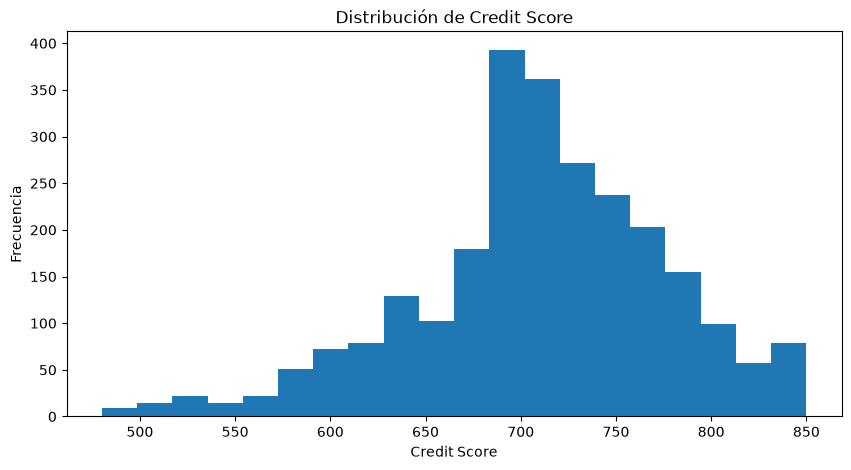

In [16]:
import matplotlib.pyplot as plt

credit_score_pd = credit_score_distribution.toPandas()

plt.figure(figsize=(10, 5))
plt.hist(
    credit_score_pd["credit_score"],
    weights=credit_score_pd["count"],
    bins=20
)

plt.title("Distribución de Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frecuencia")
plt.show()

## Distribución de tipos de tarjeta

Se representa la frecuencia de cada categoría de card_type para observar
cómo se distribuyen los registros entre los diferentes tipos.

In [17]:
card_type_distribution = (
    cards_spark
    .groupBy("card_type")
    .count()
    .orderBy(desc("count"))
)

card_type_distribution.show()

+---------------+-----+
|      card_type|count|
+---------------+-----+
|          Debit| 3813|
|         Credit| 2245|
|Debit (Prepaid)|  631|
|           NULL|   57|
+---------------+-----+



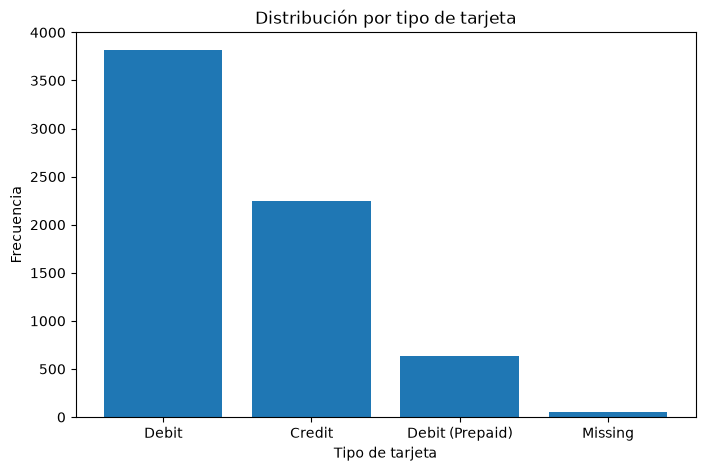

In [18]:
card_type_pd = card_type_distribution.toPandas()

card_type_pd["card_type"] = card_type_pd["card_type"].fillna("Missing")

plt.figure(figsize=(8, 5))

plt.bar(
    card_type_pd["card_type"],
    card_type_pd["count"]
)

plt.title("Distribución por tipo de tarjeta")
plt.xlabel("Tipo de tarjeta")
plt.ylabel("Frecuencia")

plt.show()

## Correlaciones

Se analizan relaciones entre variables numéricas de los usuarios y sus tarjetas. Para relacionar el credit score con el límite de crédito se combinan ambos datasets mediante el identificador del cliente.

In [19]:
users_cards_spark = (
    users_spark
    .join(
        cards_spark,
        users_spark["id"] == cards_spark["client_id"],
        "inner"
    )
)

In [20]:
credit_score_limit_corr = (
    users_cards_spark
    .select(
        col("credit_score").cast("double").alias("credit_score"),
        regexp_replace(
            col("credit_limit"),
            "[$,]",
            ""
        ).cast("double").alias("credit_limit")
    )
    .stat
    .corr("credit_score", "credit_limit")
)

print(
    f"Correlación entre Credit Score y Credit Limit: "
    f"{credit_score_limit_corr:.4f}"
)

Correlación entre Credit Score y Credit Limit: 0.0267


In [21]:
credit_score_age_corr = (
    users_spark
    .stat
    .corr("credit_score", "current_age")
)

print(
    f"Correlación entre Credit Score y Current Age: "
    f"{credit_score_age_corr:.4f}"
)

Correlación entre Credit Score y Current Age: 0.0263
